In [1]:
import torch 
from torch_geometric.data import  DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from torch.utils.data import DataLoader, Dataset
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
from matplotlib import animation

# for cleaner look (set your theme to dark mode)
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#1E1E1E'
plt.rcParams['axes.facecolor'] = '#1E1E1E'
plt.rcParams['savefig.facecolor'] = '#1E1E1E'

from tqdm import tqdm

from IPython.display import Image

In [2]:
################# quickfix for Snellius GPU MIG usage
import os 
import subprocess
if "MIG" in subprocess.check_output(["nvidia-smi", "-L"], text=True):
    os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device name: {torch.cuda.get_device_name()}")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:

from pathlib import Path
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()
base_in = PROJECT_ROOT / "data" / "CFD" / "CFD" / "grid" / "loose"
base_out2 = PROJECT_ROOT / "data" / "CFD" / "CFD" / "grid" / "concat"
# ...existing code...
base_in = PROJECT_ROOT / "data" / "CFD" / "CFD" / "grid" / "loose"
base_out2 = PROJECT_ROOT / "data" / "CFD" / "CFD" / "grid" / "concat"
os.makedirs(base_out2, exist_ok=True)
for Re in [100,150,200,250,300,350,400]:
    u = np.load(base_in / f"u_grid_Re{Re}.npy")
    v = np.load(base_in / f"v_grid_Re{Re}.npy")
    p = np.load(base_in / f"p_grid_Re{Re}.npy")
    concat = np.stack([u, v, p], axis=1)
    filename_save = base_out2 / f"uvp_grid_Re{Re}.npy"
    np.save(filename_save, concat)


class FlowDataset(Dataset):
    def __init__(self, filenames, flip_augmentation=False, timesample=1,bundle_size=6):
        self.sequences = []
        self.index_map = []
        self.flip_augmentation = flip_augmentation
        self.bundle_size = bundle_size

        # coordinates
        self.coordsy = np.linspace(-5, 5, 64, endpoint=True)
        self.coordsx = np.linspace(-10, 10, 128, endpoint=True)
        self.coords = np.array(np.meshgrid(self.coordsx, self.coordsy)).T.reshape(128, 64, 2)
        self.coords = torch.tensor(self.coords, dtype=torch.float32).permute(2, 1, 0)

        # use coordinates to make obstacle mask
        center = torch.tensor([-5.0, 0.0]).view(2, 1, 1)
        radius = 0.5
        squared_distance = ((self.coords - center) ** 2).sum(dim=0) 
        self.mask = squared_distance < radius**2  # shape [64, 128]
        self.mask = self.mask.unsqueeze(0).float()

        # sample/read the data
        for seq_idx, filename in enumerate(filenames):
            data = np.load(filename)  
            data = data[::timesample] 
            self.sequences.append(data)
            T = data.shape[0]
            self.index_map.extend([(seq_idx, t) for t in range(T - self.bundle_size)])

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        seq_idx, t = self.index_map[idx]
        seq = self.sequences[seq_idx]
        input = seq[t]    
        target_bundle = seq[t+1:t+1+self.bundle_size]
        # if flip augmentation is true then flip the data horizontally 50% of the time
        if self.flip_augmentation and np.random.rand() > 0.5:
            input = self.flip(input)
            target_bundle = np.stack([self.flip(f) for f in target_bundle], axis=0)
        return (
                self.mask,
                self.coords,
                torch.tensor(input, dtype=torch.float32), 
                torch.tensor(target_bundle, dtype=torch.float32)
                )
        
    def get_trajectory(self, seq_idx):
        # returns full trajectory
        seq = self.sequences[seq_idx]
        return (
            self.mask.unsqueeze(0), 
            self.coords.unsqueeze(0), 
            torch.tensor(seq, dtype=torch.float32)
        )

    def flip(self, x):
        x = np.flip(x, axis=2).copy()
        x[1] *= -1
        return x

datafolder = base_out2
train_files = [datafolder / f for f in ['uvp_grid_Re100.npy','uvp_grid_Re200.npy','uvp_grid_Re300.npy','uvp_grid_Re400.npy']]
val_files   = [datafolder / f for f in ['uvp_grid_Re150.npy','uvp_grid_Re250.npy','uvp_grid_Re350.npy']]
train_files = list(map(str, train_files))
val_files   = list(map(str, val_files))

dt = 20 # only sample every dt timesteps
batch_size = 64
bundle_size=6
train_dataset = FlowDataset(train_files, flip_augmentation=False, timesample=dt, bundle_size=bundle_size)
val_dataset = FlowDataset(val_files, flip_augmentation=False, timesample=dt, bundle_size=bundle_size)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [5]:
class ELBO_Loss(torch.nn.Module):
    def __init__(self, L, beta=1.0):
        super(ELBO_Loss, self).__init__()
        self.L = L
        self.beta = beta
    
    def forward(self, y_pred, y_true_bundle):
        enc_dist, prior_dist, predicted_bundle = y_pred
        # Mean over batch, channels, H, W (prevents KL from overwhelming MSE)
        kl = torch.distributions.kl.kl_divergence(enc_dist, prior_dist).mean()
        recon = torch.nn.functional.mse_loss(predicted_bundle, y_true_bundle, reduction='mean')
        return self.beta * kl + recon
        

class Encoder(torch.nn.Module):
    def __init__(self, num_layers=2, processor=None, emb_dim=64, latent_dim=16, nonlinearity = torch.nn.functional.relu):
        """
        Encoder for the AR-LVM model, takes in the node embeddings and returns a distribution over the latent space

        Args:
            num_layers: number of message passing layers
            processor: Processor model
            emb_dim: dimension of the node embeddings
            latent_dim: dimension of the latent space
            nonlinearity: activation function
        """
        super(Encoder, self).__init__()
        self.processor = processor
        self.mp_layers = torch.nn.ModuleList([torch.nn.Conv2d(emb_dim*2, emb_dim*2, kernel_size=3, padding='same') for _ in range(num_layers)])
        self.fc_mu = torch.nn.Conv2d(emb_dim*2, latent_dim, kernel_size=1)
        self.fc_sigma = torch.nn.Conv2d(emb_dim*2, latent_dim, kernel_size=1)
        self.nonlinearity = nonlinearity

    def forward(self, h, h_next): 
        """
        Args:
            h: node embeddings
            x_initial: initial state
            x_next: next state
            coords: coordinates of the nodes
            mask: mask for the obstacle

        Returns:
            torch.Distribution: Normal distribution over the latent space
        """

        h = torch.cat([h, h_next], dim=1)
        # Apply message passing layers
        for mp in self.mp_layers:
            h = mp(h)
            h = self.nonlinearity(h)
        
        # Compute the mean and sigma
        mu = self.fc_mu(h)          # Create one z per node
        sigma = self.fc_sigma(h)    # Create one z per node
        sigma = torch.nn.functional.softplus(sigma) + 1e-6
        # Create a Normal distribution with mu and sigma
        enc_dist = torch.distributions.Normal(mu, sigma)
        return enc_dist
        
    
class Processor(torch.nn.Module):
    def __init__(self, num_layers=2, in_dim=4, emb_dim=64, nonlinearity = torch.nn.functional.relu):
        """
        Forward model, takes in the input data and returns the node embeddings

        Args:
            num_layers: number of message passing layers
            in_dim: input dimension
            emb_dim: dimension of the node embeddings
            nonlinearity: activation function
        """
        super(Processor, self).__init__()
        self.in_emb = torch.nn.Conv2d(in_dim, emb_dim, kernel_size=1)
        self.mp_layers = torch.nn.ModuleList([torch.nn.Conv2d(emb_dim, emb_dim, kernel_size=3, padding='same') for _ in range(num_layers)])
        self.nonlinearity = nonlinearity


    def forward(self, x_grid): #update this
        """
        Forward pass of the Processor

        Args:
            x: input data
            edge_index: adjacency list
            edge_attr: edge attributes

        Returns:
            torch.Tensor: node embeddings
        """
        h = self.in_emb(x_grid)
        h = self.nonlinearity(h)

        for mp in self.mp_layers:
            h = mp(h)
            h = self.nonlinearity(h)

        return h

    
class Decoder(torch.nn.Module):
    def __init__(self, num_layers=2, latent_dim=16, emb_dim=64, out_dim=4, nonlinearity = torch.nn.functional.relu, sigma = 0.1):
        """
        Decoder for the AR-LVM model, takes in the node embeddings and the latent variable z and returns a distribution over the output space,
        in this case the next timestep, with fixed variance.

        Args:
            num_layers: number of message passing layers
            emb_dim: dimension of the node embeddings
            out_dim: dimension of the output space
            nonlinearity: activation function
            sigma: fixed variance
        """
        super(Decoder, self).__init__()
        self.mp_layers = torch.nn.ModuleList([torch.nn.Conv2d(emb_dim+latent_dim, emb_dim+latent_dim, kernel_size=3, padding='same') for _ in range(num_layers)])
        self.fc = torch.nn.Conv2d(emb_dim+latent_dim, out_dim, kernel_size=1)
        self.nonlinearity = nonlinearity
        self.sigma = sigma

    def forward(self, h, z): #update this
        """
        Forward pass of the Decoder. Concatenates the node embeddings and the latent variable z, then applies message passing layers
        and returns a Normal distribution over the output space

        Args:
            h: node embeddings
            z: latent variable
            edge_index: adjacency list
            edge_attr: edge attributes
        """
        # Concatenate h and z
        h_cat = torch.cat([h, z], dim=1)
        # Apply message passing layers
        for mp in self.mp_layers:
            h_cat = mp(h_cat)
            h_cat = self.nonlinearity(h_cat)
        # Apply the final linear layer
        out = self.fc(h_cat)
        # Create a Normal distribution with the output and a fixed variance
        dec_dist = torch.distributions.Normal(out, self.sigma)
        return dec_dist
        

class Prior(torch.nn.Module):
    def __init__(self, num_layers=2, emb_dim=64, latent_dim=16, nonlinearity = torch.nn.functional.relu):
        """
        Prior class for the AR-LVM model, takes in the node embeddings and returns a distribution over the latent space

        Args:
            num_layers: number of message passing layers
            emb_dim: dimension of the node embeddings
            latent_dim: dimension of the latent space
            nonlinearity: activation function
        """
        super(Prior, self).__init__()
        self.mp_layers = torch.nn.ModuleList([torch.nn.Conv2d(emb_dim, emb_dim, kernel_size=3, padding='same') for _ in range(num_layers)])
        self.fc_mu = torch.nn.Conv2d(emb_dim, latent_dim, kernel_size=1)
        self.fc_sigma = torch.nn.Conv2d(emb_dim, latent_dim, kernel_size=1)
        self.nonlinearity = nonlinearity
    
    def forward(self, h):
        """
        Args:
            h: node embeddings
            edge_index: adjacency list
            edge_attr: edge attributes

        Returns:
            torch.Distribution: Normal distribution over the latent space
        """
        # Apply message passing layers
        for mp in self.mp_layers:
            h = mp(h)
            h = self.nonlinearity(h)
        
        # Compute the mean and sigma
        mu = self.fc_mu(h)
        sigma = self.fc_sigma(h)
        sigma = torch.nn.functional.softplus(sigma) + 1e-6
        # Create a Normal distribution with mu and sigma
        prior_dist = torch.distributions.Normal(mu, sigma)
        return prior_dist


class AR_LVM_Model(torch.nn.Module):
    def __init__(self, encoder=None, processor=None, decoder=None, prior=None, use_mask=True, use_coords=False,
                 predict_residual=True):
        super(AR_LVM_Model, self).__init__()
        self.encoder = encoder
        self.processor = processor
        self.decoder = decoder
        self.prior = prior
        self.use_mask = use_mask
        self.use_coords = use_coords
        self.predict_residual = predict_residual

    def _make_input(self, x, mask, coords):
        feats = [x]
        if self.use_mask:
            feats.append(mask)     # (1, H, W)
        if self.use_coords:
            feats.append(coords)   # (2, H, W)
        return torch.cat(feats, dim=1)

    def forward(self, x_t, target_bundle, mask, coords, teacher_forcing=False):
        """
        Forward pass of the AR-LVM model for grid data.
        """
        bundle_size = target_bundle.shape[1]
        input_ar = self._make_input(x_t, mask, coords)
        first_future = target_bundle[:, 0]
        h_t = self.processor(input_ar)
        h_next = self.processor(self._make_input(first_future, mask, coords))
        enc_dist = self.encoder(h_t, h_next)
        z_inf = enc_dist.rsample()
        prior_dist = self.prior(h_t)

        generated_frames = []
        current_x = x_t
        for s in range(bundle_size):
            h_step = self.processor(self._make_input(current_x, mask, coords))
            out_dist = self.decoder(h_step, z_inf)
            step_pred = out_dist.loc
            current_x = current_x + step_pred if self.predict_residual else step_pred
            generated_frames.append(current_x)
            if teacher_forcing:
                current_x = target_bundle[:, s]
        predicted_bundle = torch.stack(generated_frames, dim=1)
        return (enc_dist, prior_dist, predicted_bundle)

    def sample(self, mask, coords, x_t):
        """
        Sample from the AR-LVM model with grid data.
        """
        h = self.processor(self._make_input(x_t, mask, coords))
        prior_dist = self.prior(h)
        z = prior_dist.rsample()
        out = self.decoder(h, z)
        return out.loc



In [6]:
use_mask = True
use_coords = True  # set True to add the 2 coordinate channels (x,y)

in_dim = 3 + (1 if use_mask else 0) + (2 if use_coords else 0)

processor = Processor(num_layers=4, in_dim=in_dim, emb_dim=64, nonlinearity=torch.nn.functional.relu)
lvm_cfd = AR_LVM_Model(
    encoder=Encoder(num_layers=2, emb_dim=64, latent_dim=16, nonlinearity=torch.nn.functional.relu),
    processor=processor,
    decoder=Decoder(num_layers=2, latent_dim=16, emb_dim=64, out_dim=3, nonlinearity=torch.nn.functional.relu, sigma=0.1),
    prior=Prior(num_layers=2, emb_dim=64, latent_dim=16, nonlinearity=torch.nn.functional.relu),
    use_mask=use_mask,
    use_coords=use_coords,
)

Loading model from file...


<All keys matched successfully>

In [8]:
# helper functions
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def rollout(model, mask, coords, init_frame, length=100):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        current_frame = init_frame.to(device)
        mask = mask.to(device)
        coords = coords.to(device)
        output_sequence = [init_frame.squeeze(0).cpu()]
        for _ in range(length):
            output = model.sample(mask, coords, current_frame)
            output_sequence.append(output.squeeze(0).cpu())
            current_frame = output
    return torch.stack(output_sequence)

def magnitude(tensor):
    # calculates the radial componentn/magnitude of the 2D velocity field
    return torch.sqrt(tensor[:,0,:,:]**2 + tensor[:,1,:,:]**2)

def animate_rollout(stacked_pred_vel, stacked_true_vel, stacked_pred_p, stacked_true_p, output_path="output/rollout.gif"):
    # this function makes the animation file, given the predicted and true velocity and pressure fields
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    timesteps, x_dim, y_dim = stacked_pred_vel.shape
    if timesteps > stacked_true_vel.shape[0]:
        timesteps = stacked_true_vel.shape[0]
    stacked_pred_vel, stacked_true_vel = stacked_pred_vel.squeeze(1).cpu().numpy(), stacked_true_vel.squeeze(1).cpu().numpy()
    stacked_pred_p, stacked_true_p = stacked_pred_p.squeeze(1).cpu().numpy(), stacked_true_p.squeeze(1).cpu().numpy()
    vmax_vel = min(np.max(stacked_pred_vel), np.max(stacked_true_vel))
    vmax_p = min(np.max(stacked_pred_p), np.max(stacked_true_p))
    fig, axes = plt.subplots(2, 3, figsize=(15, 5))
    titles = ["Pred", "True", "Diff"]
    imgs = []

    for i in range(2):
        row_imgs = []
        for j in range(3):
            ax = axes[i, j]
            img = ax.imshow(np.zeros((x_dim, y_dim)), cmap='viridis', vmin=0, vmax=vmax_vel if i == 0 else vmax_p)
            ax.set_title(titles[j])
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            row_imgs.append(img)
        imgs.append(row_imgs)

    axes[0,0].set_ylabel(r'$\sqrt{v_x^2 + v_y^2}$')
    axes[1,0].set_ylabel(r'$p$')
    imgs[0][2].set_cmap('magma')
    imgs[1][2].set_cmap('magma')
    
    def init():
        imgs[0][0].set_data(stacked_pred_vel[0])
        imgs[0][1].set_data(stacked_true_vel[0])
        imgs[1][0].set_data(stacked_pred_p[0])
        imgs[1][1].set_data(stacked_true_p[0])
        return imgs

    def update(frame):

        imgs[0][0].set_data(stacked_pred_vel[frame])
        imgs[0][1].set_data(stacked_true_vel[frame])
        imgs[1][0].set_data(stacked_pred_p[frame])
        imgs[1][1].set_data(stacked_true_p[frame])
        imgs[0][2].set_data(np.abs(stacked_true_vel[frame] - stacked_pred_vel[frame]))
        imgs[1][2].set_data(np.abs(stacked_true_p[frame] - stacked_pred_p[frame]))

        fig.suptitle(f"timestep {frame + 1}\n"
                     #f"vmin: {vmin_frame:.4f}, vmax: {vmax_frame:.4f}")
                        #f"vmax: {vmax_frame:.3f}"
                        )
        return imgs

    ani = animation.FuncAnimation(fig, update, frames=timesteps, init_func=init, blit=False, interval=150)
    ani.save(output_path, writer="ffmpeg")
    plt.close()

def _generate_sequence(model, val_dataset, starting_timestep, length, trajectory_select=1):
    model.eval()
    with torch.no_grad():
        mask, coords, val_traj = val_dataset.get_trajectory(trajectory_select)
        mask, coords, val_traj = mask.to(device), coords.to(device), val_traj.to(device)
        val_traj = val_traj[starting_timestep:]
        anim_data = rollout(model, mask, coords, val_traj[0].unsqueeze(0), length=length)
        velocity = magnitude(anim_data).cpu()
        velocity_test = magnitude(val_traj).cpu()
        pressure = anim_data[:, 2, :, :].cpu()
        pressure_test = val_traj[:, 2, :, :].cpu()
    return velocity, velocity_test, pressure, pressure_test
def plot_comparison(velocity, velocity_test, pressure, pressure_test):
    # this function plots the comparison between predicted and true fields at some timesteps
    fig, ax = plt.subplots(4, 4, figsize=(10, 7))
    timesteps = [0, 1, 5, 10]
    for i, t in enumerate(timesteps):
        # turn axis off
        for j in range(4):
            # only remove axis ticks
            ax[i, j].set_xticks([])
            ax[i, j].set_yticks([])
            for spine in ax[i, j].spines.values():
                spine.set_visible(False)
        # plot the velocity magnitude and pressure at each time step
        ax[i, 0].imshow(velocity[t].numpy(), cmap='viridis')
        ax[i, 2].imshow(pressure[t].numpy(), cmap='viridis')
        ax[i, 1].imshow(velocity_test[t].numpy(), cmap='viridis')
        ax[i, 3].imshow(pressure_test[t].numpy(), cmap='viridis')
    ax[0, 0].set_title('Predicted Velocity Magnitude')
    ax[0, 2].set_title('Predicted Pressure')
    ax[0, 1].set_title('True Velocity Magnitude')
    ax[0, 3].set_title('True Pressure')
    ax[0, 0].set_ylabel('t={t}'.format(t=timesteps[0]))
    ax[1, 0].set_ylabel('t={t}'.format(t=timesteps[1]))
    ax[2, 0].set_ylabel('t={t}'.format(t=timesteps[2]))
    ax[3, 0].set_ylabel('t={t}'.format(t=timesteps[3]))
    plt.tight_layout()
    plt.show()

In [12]:

print("Loading model from file...")
lvm_cfd.load_state_dict(torch.load('../../models/CFD/02-LV-TB.pt'))


Loading model from file...


<All keys matched successfully>

MovieWriter ffmpeg unavailable; using Pillow instead.


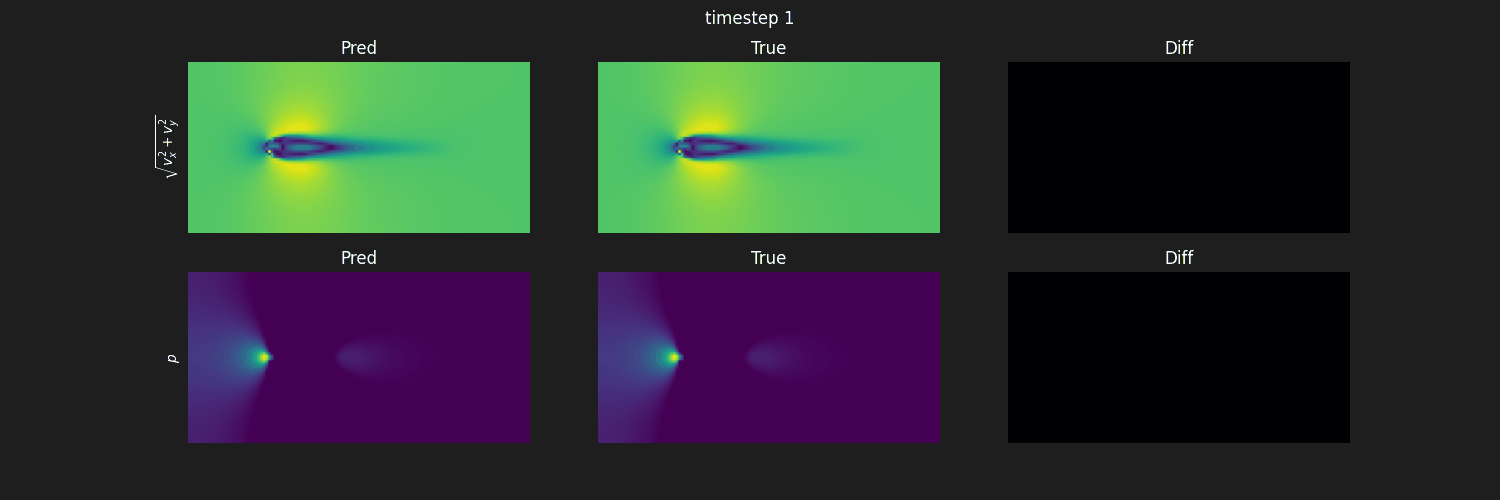

In [13]:
starting_timestep = 6
model=lvm_cfd
velocity, velocity_true, pressure, pressure_true = _generate_sequence(model, val_dataset, starting_timestep, length=41, trajectory_select=1)
animate_rollout(velocity, velocity_true, pressure, pressure_true, output_path="output/rollout_model1.gif")
Image(filename="output/rollout_model1.gif")